# Production Reconstruction Evaluation (per batch, kW sensors)

Question: **if I simulate the whole test period with my pipeline (process model -> durations, curve model -> energy shapes), does the production energy come out right?**

We do NOT compare curves minute-by-minute (a single wrong duration would shift everything). Instead we compare **per-batch aggregates**, which are immune to time-shift:
- **Total energy per batch** (the main number)
- **Max per batch** (peak kW during the batch)
- **Min per batch** (~0 for per-machine sensors, kept for completeness)

The reconstruction uses **only simulated information** (simulated durations -> curve lengths): a true forecast, it never peeks at real durations.

Only sensors with **`kw`** in their name are evaluated.

> Curve model = per-activity training **barycenter (mean curve)** proxy. Swap the body of `predict_curve` for the trained pipeline's predict to score the real model.

In [1]:
import os, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Markdown
warnings.filterwarnings('ignore')

REPO    = Path(os.path.abspath('')).resolve()
REPO    = REPO.parent if REPO.name == 'src' else REPO
DATA    = REPO / 'data' / 'gold' / 'experiment_1'
RESULTS = REPO / 'results'
EXP     = sorted(RESULTS.glob('experiment_405_*'))[-1]
PROCESSES = ['process_1', 'process_2', 'process_3', 'process_4']
CANON = 20
print('Experiment:', EXP.name)

Experiment: experiment_405_20260629_081127


In [2]:
def resample(a, n):
    a = np.asarray(a, float)
    if n <= 0: return np.array([])
    if len(a) == n: return a
    if len(a) <= 1: return np.full(n, a[0] if len(a) else 0.0)
    return np.interp(np.linspace(0,1,n), np.linspace(0,1,len(a)), a)

def build_barycenter(exp_train, sensor):
    bary = {}
    for act, g in exp_train.groupby('activity_log'):
        cs = [resample(i.sort_values('datetime_energy')[sensor].values.astype(float), CANON)
              for _, i in g.groupby('timestamp_start_log')]
        if cs:
            bary[str(act)] = np.mean(np.vstack(cs), axis=0)
    return bary

def rows_per_minute(exp_train):
    rpm = {}
    for act, g in exp_train.groupby('activity_log'):
        rows, durs = [], []
        for _, i in g.groupby('timestamp_start_log'):
            d = (pd.to_datetime(i['timestamp_end_log'].iloc[-1])
                 - pd.to_datetime(i['timestamp_start_log'].iloc[0])).total_seconds() / 60.0
            if d > 0: rows.append(len(i)); durs.append(d)
        rpm[str(act)] = (np.sum(rows)/np.sum(durs)) if durs and np.sum(durs) > 0 else 1.0
    return rpm

def predict_curve(bary, activity, length):
    """Replace this body with the trained pipeline predict() to score the real model."""
    length = max(1, int(length))
    if activity in bary:
        return resample(bary[activity], length)
    return np.zeros(length)

def sim_durations(simlog):
    d = simlog.copy()
    d['timestamp_start'] = pd.to_datetime(d['timestamp_start'])
    d['timestamp_end']   = pd.to_datetime(d['timestamp_end'])
    d['_dur'] = (d['timestamp_end'] - d['timestamp_start']).dt.total_seconds() / 60.0
    return d

def wape(real, rec):
    real, rec = np.asarray(real, float), np.asarray(rec, float)
    den = np.abs(real).sum()
    return 100 * np.abs(real - rec).sum() / den if den > 0 else np.nan

print('Helpers ready.')

Helpers ready.


## Per-batch reconstruction for all processes (kW sensors only)

In [3]:
pe = pd.read_parquet(EXP / 'process_eval_results.parquet')
per_batch = {}
meta = {}

for proc in PROCESSES:
    exp = pd.read_parquet(DATA / proc / 'datasets' / 'df_expanded.parquet')
    sensors = [c for c in exp.columns if 'kw' in c.lower() and c.endswith('_energy_to_model')]
    if not sensors:
        print(f'{proc}: no kW sensors, skipping'); continue
    testlog = pd.read_parquet(EXP / 'predicted_logs' / f'{proc}_test_set.parquet')
    test_cases = set(testlog['case_id'].unique())
    exp_test  = exp[exp['case_id_log'].isin(test_cases)].copy()
    exp_train = exp[~exp['case_id_log'].isin(test_cases) & exp['case_id_log'].notna()].copy()
    pep = pe[pe['process'] == proc].dropna(subset=['test_duration_metrics_activity_duration_wape'])
    best = pep.loc[pep['test_duration_metrics_activity_duration_wape'].idxmin(), 'mode'] if not pep.empty else 'statistical'
    sp = EXP / 'predicted_logs' / f'{proc}_{best}.parquet'
    simlog = pd.read_parquet(sp) if sp.exists() else testlog.copy()
    meta[proc] = best
    rpm  = rows_per_minute(exp_train)
    simd = sim_durations(simlog)
    common = []
    for sensor in sensors:
        bary = build_barycenter(exp_train, sensor)
        real = exp_test.groupby('case_id_log')[sensor].agg(['sum','min','max'])
        real.index = real.index.astype(str)
        rec = {}
        for cid, g in simd.groupby('case_id'):
            vals = []
            for _, r in g.iterrows():
                act = str(r['activity'])
                if act not in bary: continue
                L = max(1, int(round(r['_dur'] * rpm.get(act, 1.0))))
                vals.append(predict_curve(bary, act, L))
            if vals:
                v = np.concatenate(vals)
                rec[str(cid)] = (v.sum(), v.min(), v.max())
        rec = pd.DataFrame(rec, index=['sum','min','max']).T
        common = sorted(set(real.index) & set(rec.index))
        if not common: continue
        per_batch[(proc, sensor)] = pd.DataFrame({
            'real_sum': real.loc[common,'sum'], 'rec_sum': rec.loc[common,'sum'],
            'real_max': real.loc[common,'max'], 'rec_max': rec.loc[common,'max'],
            'real_min': real.loc[common,'min'], 'rec_min': rec.loc[common,'min'],
        })
    print(f'{proc}: best mode = {best} | kW sensors = {len(sensors)} | batches = {len(common)}')

process_1: best mode = petri_net_alpha_ml_plus_per_act | kW sensors = 6 | batches = 657


process_2: best mode = petri_net_alpha_ml_plus_global | kW sensors = 2 | batches = 15


process_3: best mode = petri_net_inductive | kW sensors = 3 | batches = 95
process_4: no kW sensors, skipping


## Metrics table - per sensor

In [4]:
rows = []
for (proc, sensor), df in per_batch.items():
    rows.append(dict(
        process=proc, sensor=sensor.replace('_energy_to_model',''), n_batches=len(df),
        total_energy_WAPE=wape(df['real_sum'], df['rec_sum']),
        max_WAPE=wape(df['real_max'], df['rec_max']),
        min_WAPE=wape(df['real_min'], df['rec_min']),
        whole_period_total_err=100*abs(df['rec_sum'].sum()-df['real_sum'].sum())/df['real_sum'].sum()
                               if df['real_sum'].sum() > 0 else np.nan))
metrics = pd.DataFrame(rows)
display(Markdown('### Per-batch reconstruction error (%) - lower is better'))
display(metrics.style.format({c:'{:.1f}' for c in metrics.columns if metrics[c].dtype!=object})
        .background_gradient(cmap='RdYlGn_r', subset=['total_energy_WAPE','whole_period_total_err'])
        .set_caption('min ~ 0 by construction (machine off during other activities)'))

### Per-batch reconstruction error (%) - lower is better

,process,sensor,n_batches,total_energy_WAPE,max_WAPE,min_WAPE,whole_period_total_err
0,process_1,destillation_steam_demand_kW,657.0,127.1,123.5,nan,9.8
1,process_1,autoclave_steam_demand_kW,657.0,12.2,6.3,nan,6.5
2,process_1,autoclave_cooling_water_demand_kW,657.0,32.9,14.6,nan,32.6
3,process_1,bottling_power_kW,657.0,9.6,4.5,nan,6.1
4,process_1,packaging_power_kW,657.0,20.1,6.2,nan,17.6
5,process_1,water_supply_power_kW,657.0,9.5,4.7,nan,6.0
6,process_2,pro_power_kW,15.0,84.0,47.6,nan,84.0
7,process_2,medium_power_kW,15.0,93.5,76.1,nan,93.5
8,process_3,(17)_leistung_turmF_luftentfeuchter_kw,95.0,164.1,18.0,15.4,151.6
9,process_3,(33)_q_lufterwearmung_dampgemessen_und_berechnete_recu_kw,95.0,nan,nan,nan,100.0


## Money plot - real vs reconstructed total energy per batch
Each dot = one batch. On the diagonal = perfectly recreated.

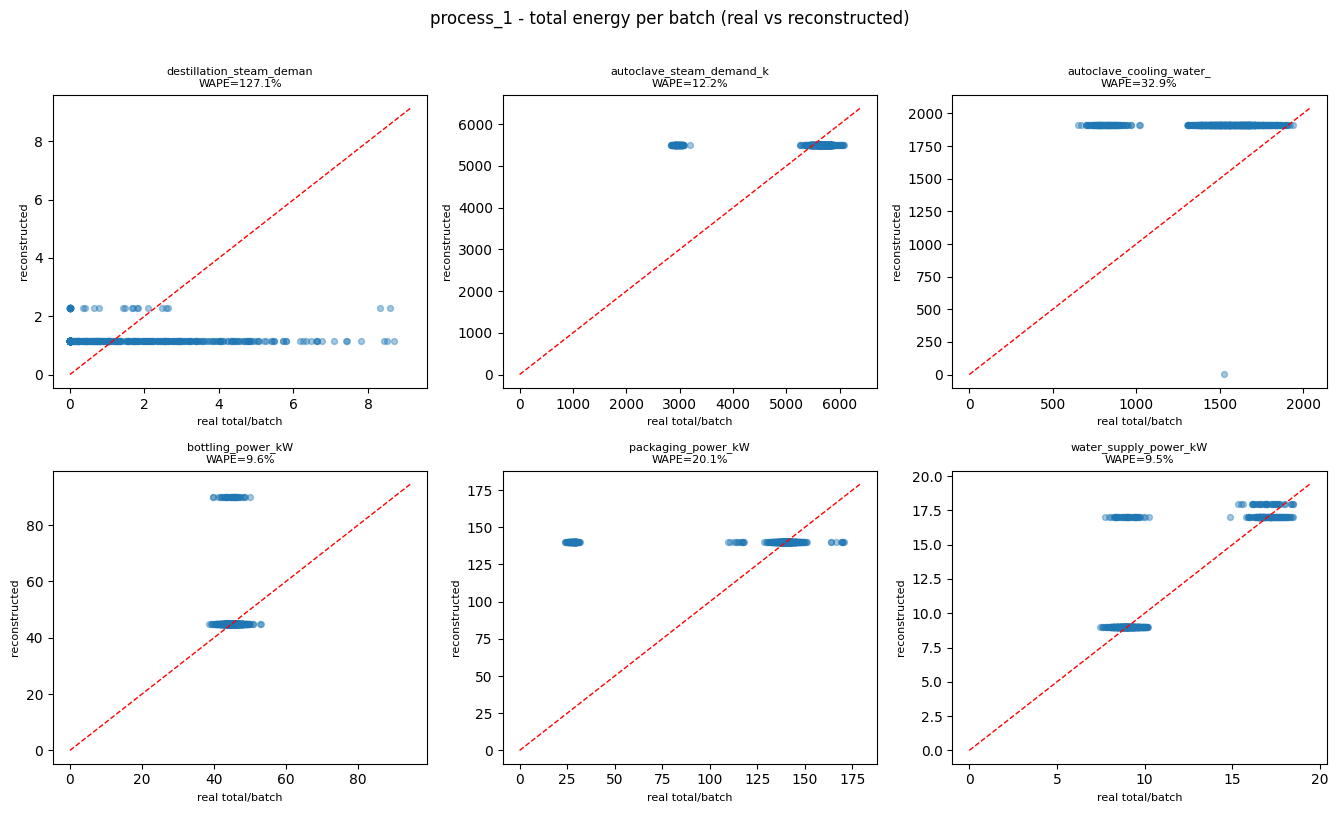

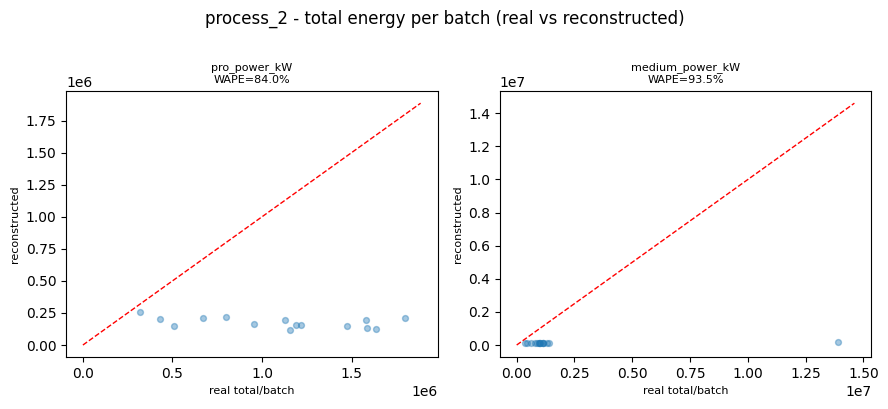

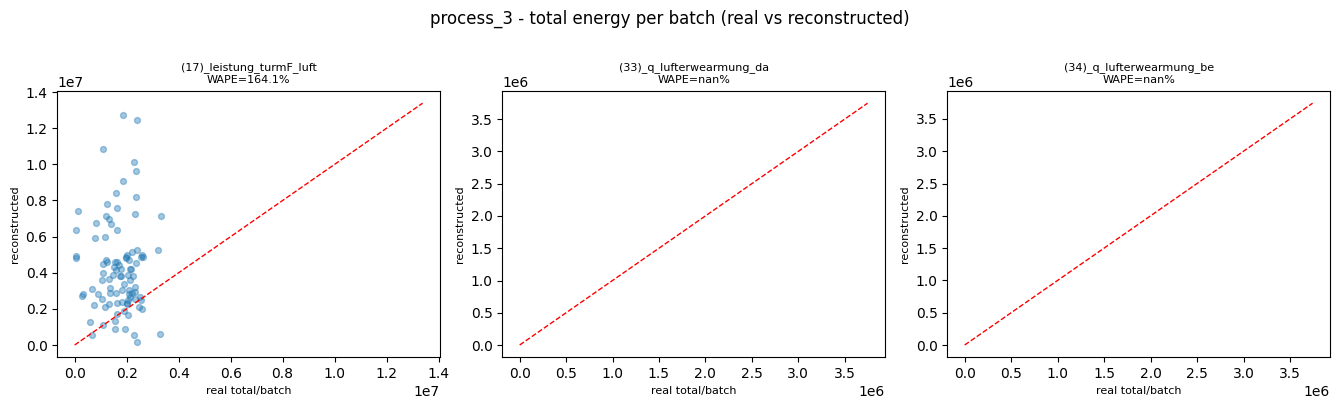

In [5]:
for proc in PROCESSES:
    sens = [k for k in per_batch if k[0] == proc]
    if not sens: continue
    ncol = min(3, len(sens)); nrow = int(np.ceil(len(sens)/ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.5*ncol, 4*nrow))
    axes = np.array(axes).flatten()
    for ax, key in zip(axes, sens):
        df = per_batch[key]
        x, y = df['real_sum'].values, df['rec_sum'].values
        mx = max(x.max(), y.max())*1.05 if len(x) else 1
        ax.scatter(x, y, alpha=0.4, s=18)
        ax.plot([0,mx],[0,mx],'r--',lw=1)
        ax.set_title(f"{key[1].replace('_energy_to_model','')[:24]}\nWAPE={wape(x,y):.1f}%", fontsize=8)
        ax.set_xlabel('real total/batch', fontsize=8); ax.set_ylabel('reconstructed', fontsize=8)
    for j in range(len(sens), len(axes)): axes[j].set_visible(False)
    fig.suptitle(f'{proc} - total energy per batch (real vs reconstructed)', y=1.01)
    plt.tight_layout(); plt.show()

## Peak (max) per batch - real vs reconstructed

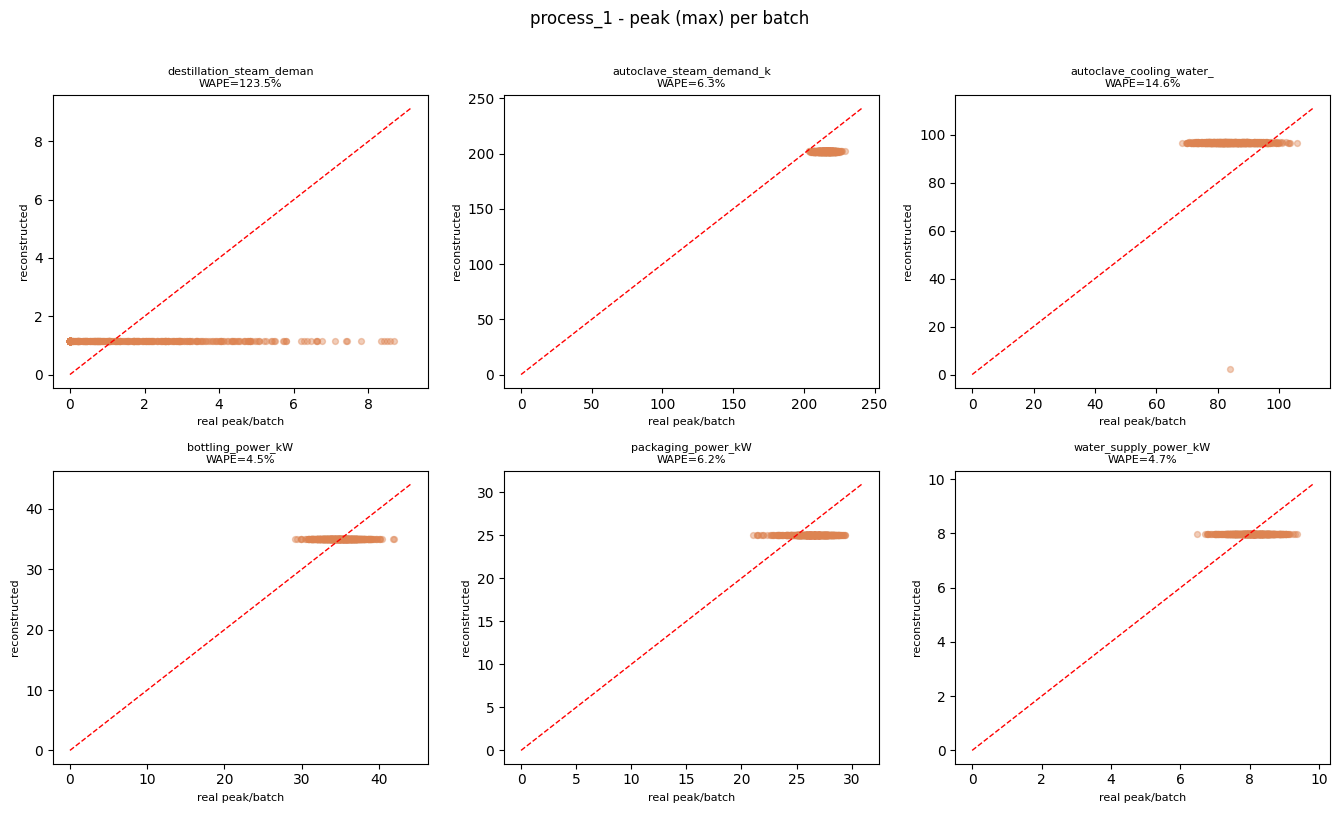

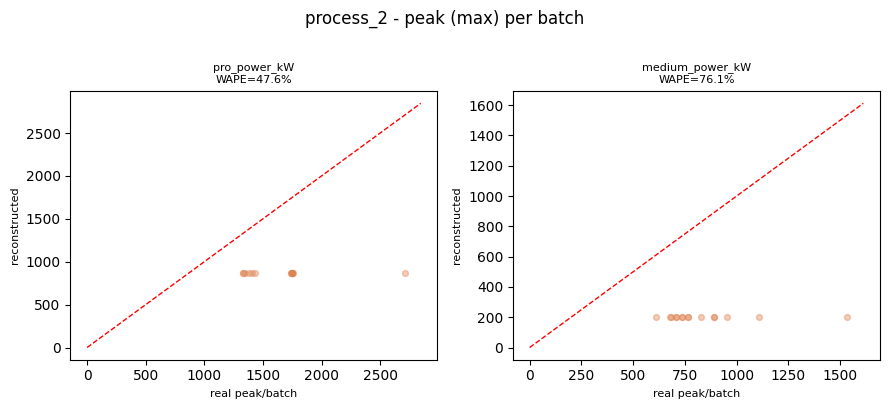

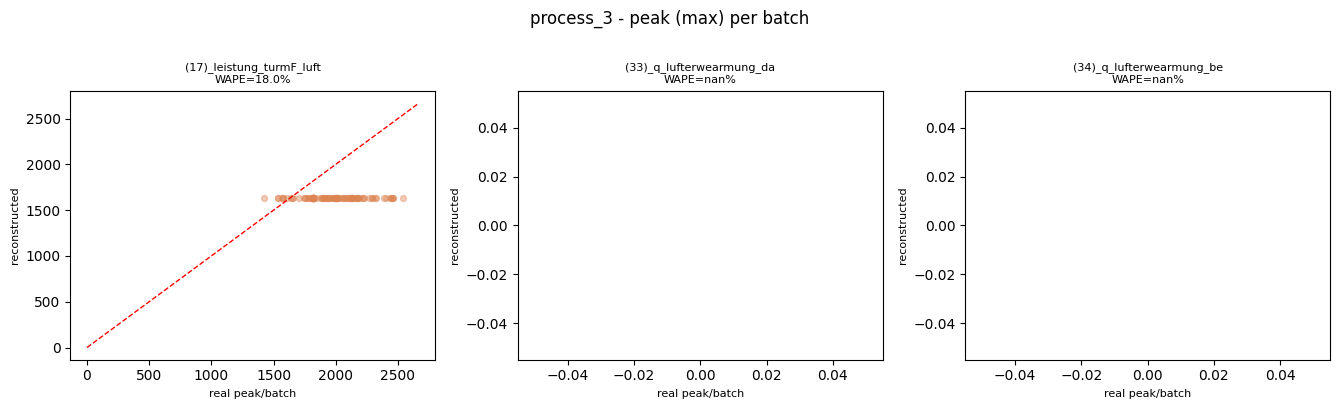

In [6]:
for proc in PROCESSES:
    sens = [k for k in per_batch if k[0] == proc]
    if not sens: continue
    ncol = min(3, len(sens)); nrow = int(np.ceil(len(sens)/ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.5*ncol, 4*nrow))
    axes = np.array(axes).flatten()
    for ax, key in zip(axes, sens):
        df = per_batch[key]
        x, y = df['real_max'].values, df['rec_max'].values
        mx = max(x.max(), y.max())*1.05 if len(x) else 1
        ax.scatter(x, y, alpha=0.4, s=18, color='#dd8452')
        ax.plot([0,mx],[0,mx],'r--',lw=1)
        ax.set_title(f"{key[1].replace('_energy_to_model','')[:24]}\nWAPE={wape(x,y):.1f}%", fontsize=8)
        ax.set_xlabel('real peak/batch', fontsize=8); ax.set_ylabel('reconstructed', fontsize=8)
    for j in range(len(sens), len(axes)): axes[j].set_visible(False)
    fig.suptitle(f'{proc} - peak (max) per batch', y=1.01)
    plt.tight_layout(); plt.show()

## Whole-period total energy per sensor

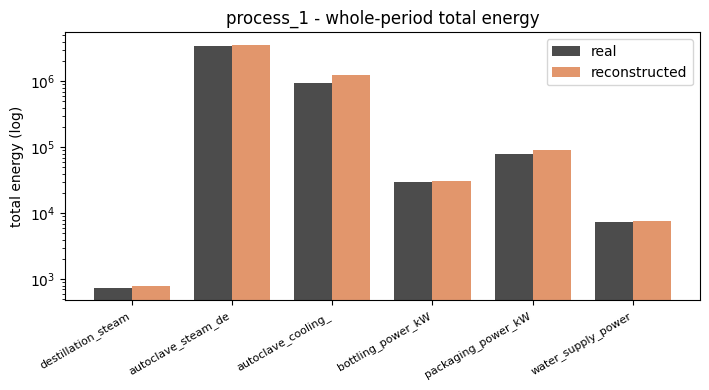

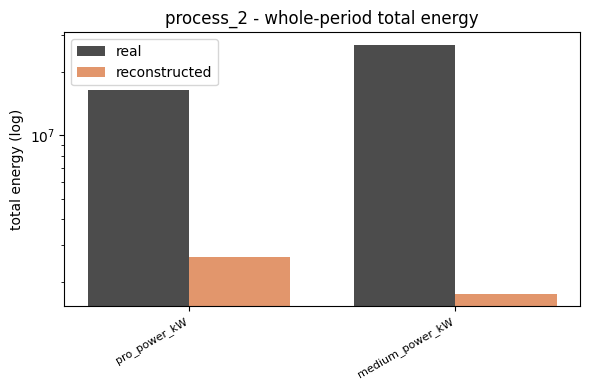

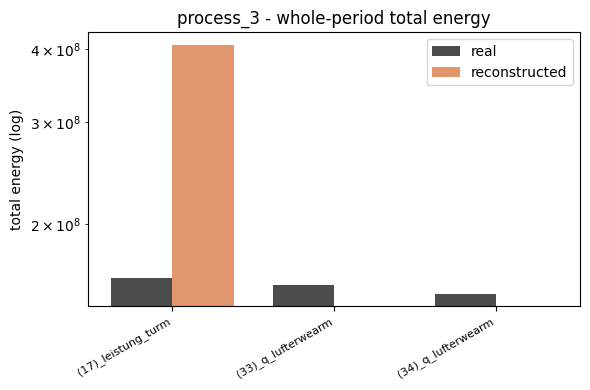

In [7]:
for proc in PROCESSES:
    sens = [k for k in per_batch if k[0] == proc]
    if not sens: continue
    labels = [k[1].replace('_energy_to_model','')[:18] for k in sens]
    real_t = [per_batch[k]['real_sum'].sum() for k in sens]
    rec_t  = [per_batch[k]['rec_sum'].sum()  for k in sens]
    x = np.arange(len(sens)); w = 0.38
    fig, ax = plt.subplots(figsize=(max(6, 1.2*len(sens)), 4))
    ax.bar(x-w/2, real_t, w, label='real', color='black', alpha=0.7)
    ax.bar(x+w/2, rec_t,  w, label='reconstructed', color='#dd8452', alpha=0.85)
    ax.set_yscale('log'); ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('total energy (log)'); ax.set_title(f'{proc} - whole-period total energy'); ax.legend()
    plt.tight_layout(); plt.show()

## Summary

In [8]:
summ = (metrics.groupby('process')
        .agg(best_mode=('process', lambda s: meta[s.iloc[0]]),
             kW_sensors=('sensor','count'),
             median_total_energy_WAPE=('total_energy_WAPE','median'),
             median_max_WAPE=('max_WAPE','median'),
             median_whole_period_err=('whole_period_total_err','median')))
display(summ.style.format({c:'{:.1f}' for c in summ.columns if summ[c].dtype!=object}))
print('\nReading guide:')
print(' - total_energy_WAPE : per-batch energy reconstruction error (headline)')
print(' - max_WAPE          : per-batch peak draw error')
print(' - whole_period_err  : error on the grand total over the whole test period')

,best_mode,kW_sensors,median_total_energy_WAPE,median_max_WAPE,median_whole_period_err
process,,,,,
process_1,petri_net_alpha_ml_plus_per_act,6.0,16.1,6.3,8.1
process_2,petri_net_alpha_ml_plus_global,2.0,88.7,61.8,88.7
process_3,petri_net_inductive,3.0,164.1,18.0,100.0



Reading guide:
 - total_energy_WAPE : per-batch energy reconstruction error (headline)
 - max_WAPE          : per-batch peak draw error
 - whole_period_err  : error on the grand total over the whole test period


---
## Curve Prediction Evaluation: MAE & WAPE per Process × Approach

Loaded from `curve_eval_results.parquet` (activity-level curve fits, TEST split).  
Each cell = **median across all (sensor, activity) pairs** for that process.  
Rows where WAPE is NaN are excluded (real signal is flat-zero — predicting 0 is trivially perfect).

Curve eval from: experiment_405_20260626_093540


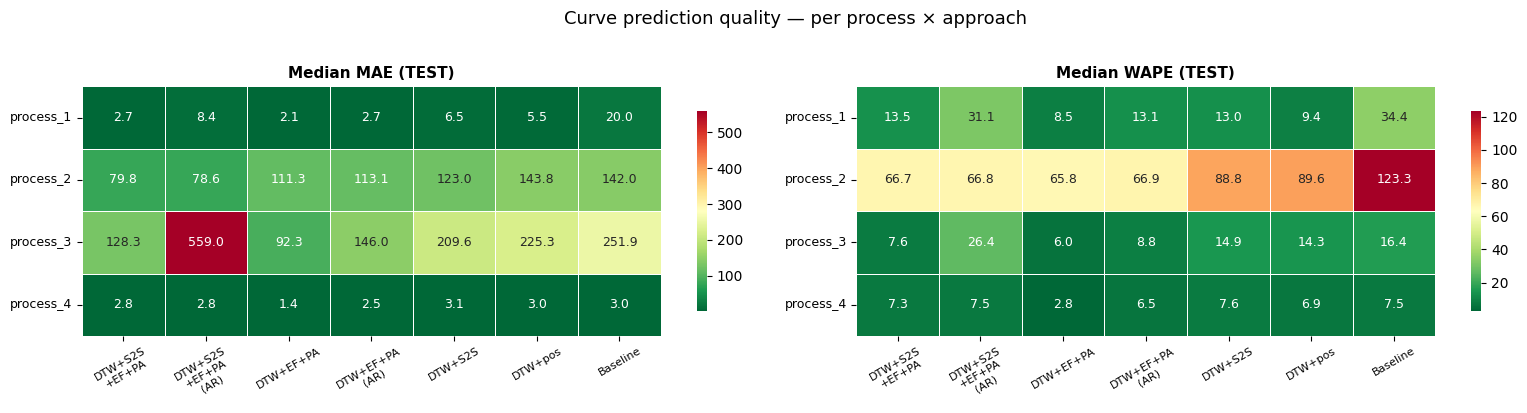

In [9]:
import seaborn as sns

# Use the latest experiment that actually has curve_eval_results.parquet
curve_exps = sorted(
    p for p in RESULTS.glob('experiment_405_*')
    if (p / 'curve_eval_results.parquet').exists()
)
CURVE_EXP = curve_exps[-1]
print('Curve eval from:', CURVE_EXP.name)

curve = pd.read_parquet(CURVE_EXP / 'curve_eval_results.parquet')

# Shorten approach names for display
short = {
    'Baseline':                                            'Baseline',
    'DTW + pos':                                           'DTW+pos',
    'DTW + Ext. Factors + Prev Act':                       'DTW+EF+PA',
    'DTW + Ext. Factors + Prev Act (autoreg)':             'DTW+EF+PA\n(AR)',
    'DTW + Seq2Seq':                                       'DTW+S2S',
    'DTW + Seq2Seq + Ext. Factors + Prev Act':             'DTW+S2S\n+EF+PA',
    'DTW + Seq2Seq + Ext. Factors + Prev Act (autoreg)':   'DTW+S2S\n+EF+PA\n(AR)',
    # older naming
    'Mean Baseline':                                       'Baseline',
    'Instance Stats (leaky)':                              'IS(leaky)',
    'Instance Stats (leak-free)':                          'IS(clean)',
    'Seq2Seq only':                                        'S2S only',
}
curve['Approach_short'] = curve['Approach'].map(lambda x: short.get(x, x))

# TEST split only; drop NaN WAPE (flat-zero signals where error is meaningless)
test = curve[(curve['Split'] == 'TEST') & curve['WAPE'].notna()].copy()

# Aggregate: median per process × approach
agg = (test.groupby(['Process', 'Approach_short'])[['MAE', 'WAPE']]
       .median()
       .reset_index())

approach_order = (agg.groupby('Approach_short')['MAE'].median()
                  .sort_values().index.tolist())

def draw_heatmap(metric, ax, fmt='.1f', cmap='RdYlGn_r'):
    pivot = agg.pivot(index='Process', columns='Approach_short', values=metric)
    pivot = pivot[[c for c in approach_order if c in pivot.columns]]
    pivot = pivot.reindex(sorted(pivot.index))
    sns.heatmap(pivot, ax=ax, annot=True, fmt=fmt, cmap=cmap,
                linewidths=0.4, linecolor='white',
                annot_kws={'size': 9}, cbar_kws={'shrink': 0.8})
    ax.set_title(f'Median {metric} (TEST)', fontsize=11, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=8, rotation=30)
    ax.tick_params(axis='y', labelsize=9, rotation=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
draw_heatmap('MAE',  axes[0])
draw_heatmap('WAPE', axes[1])
fig.suptitle('Curve prediction quality — per process × approach', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

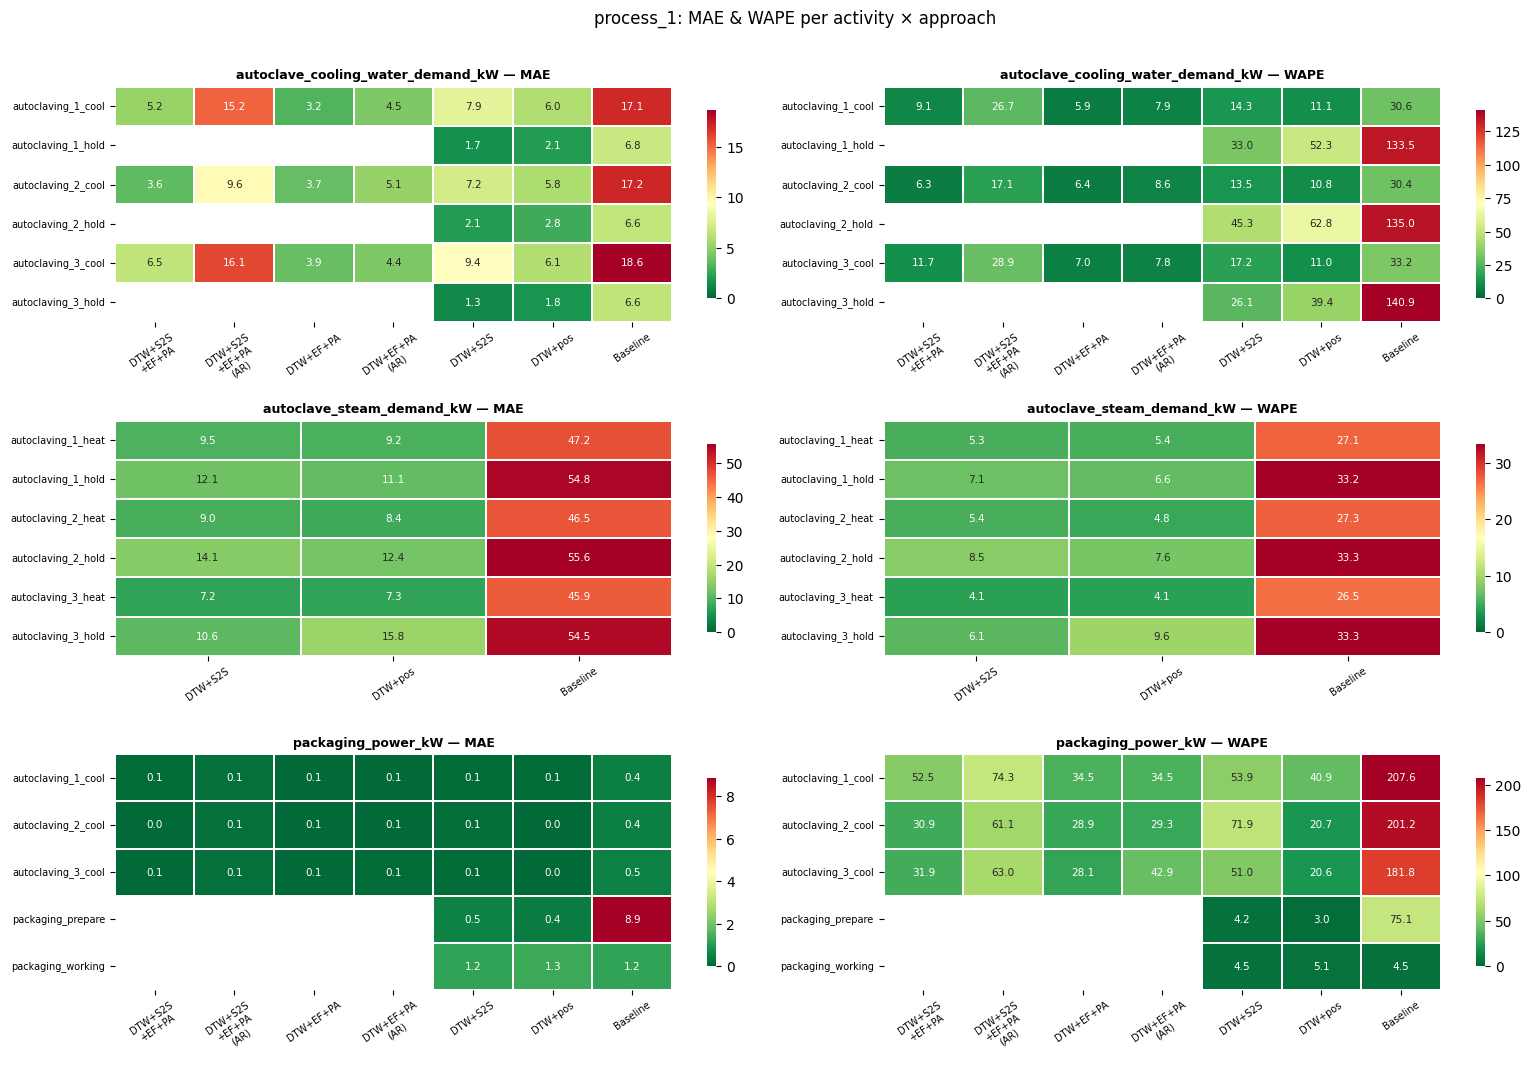

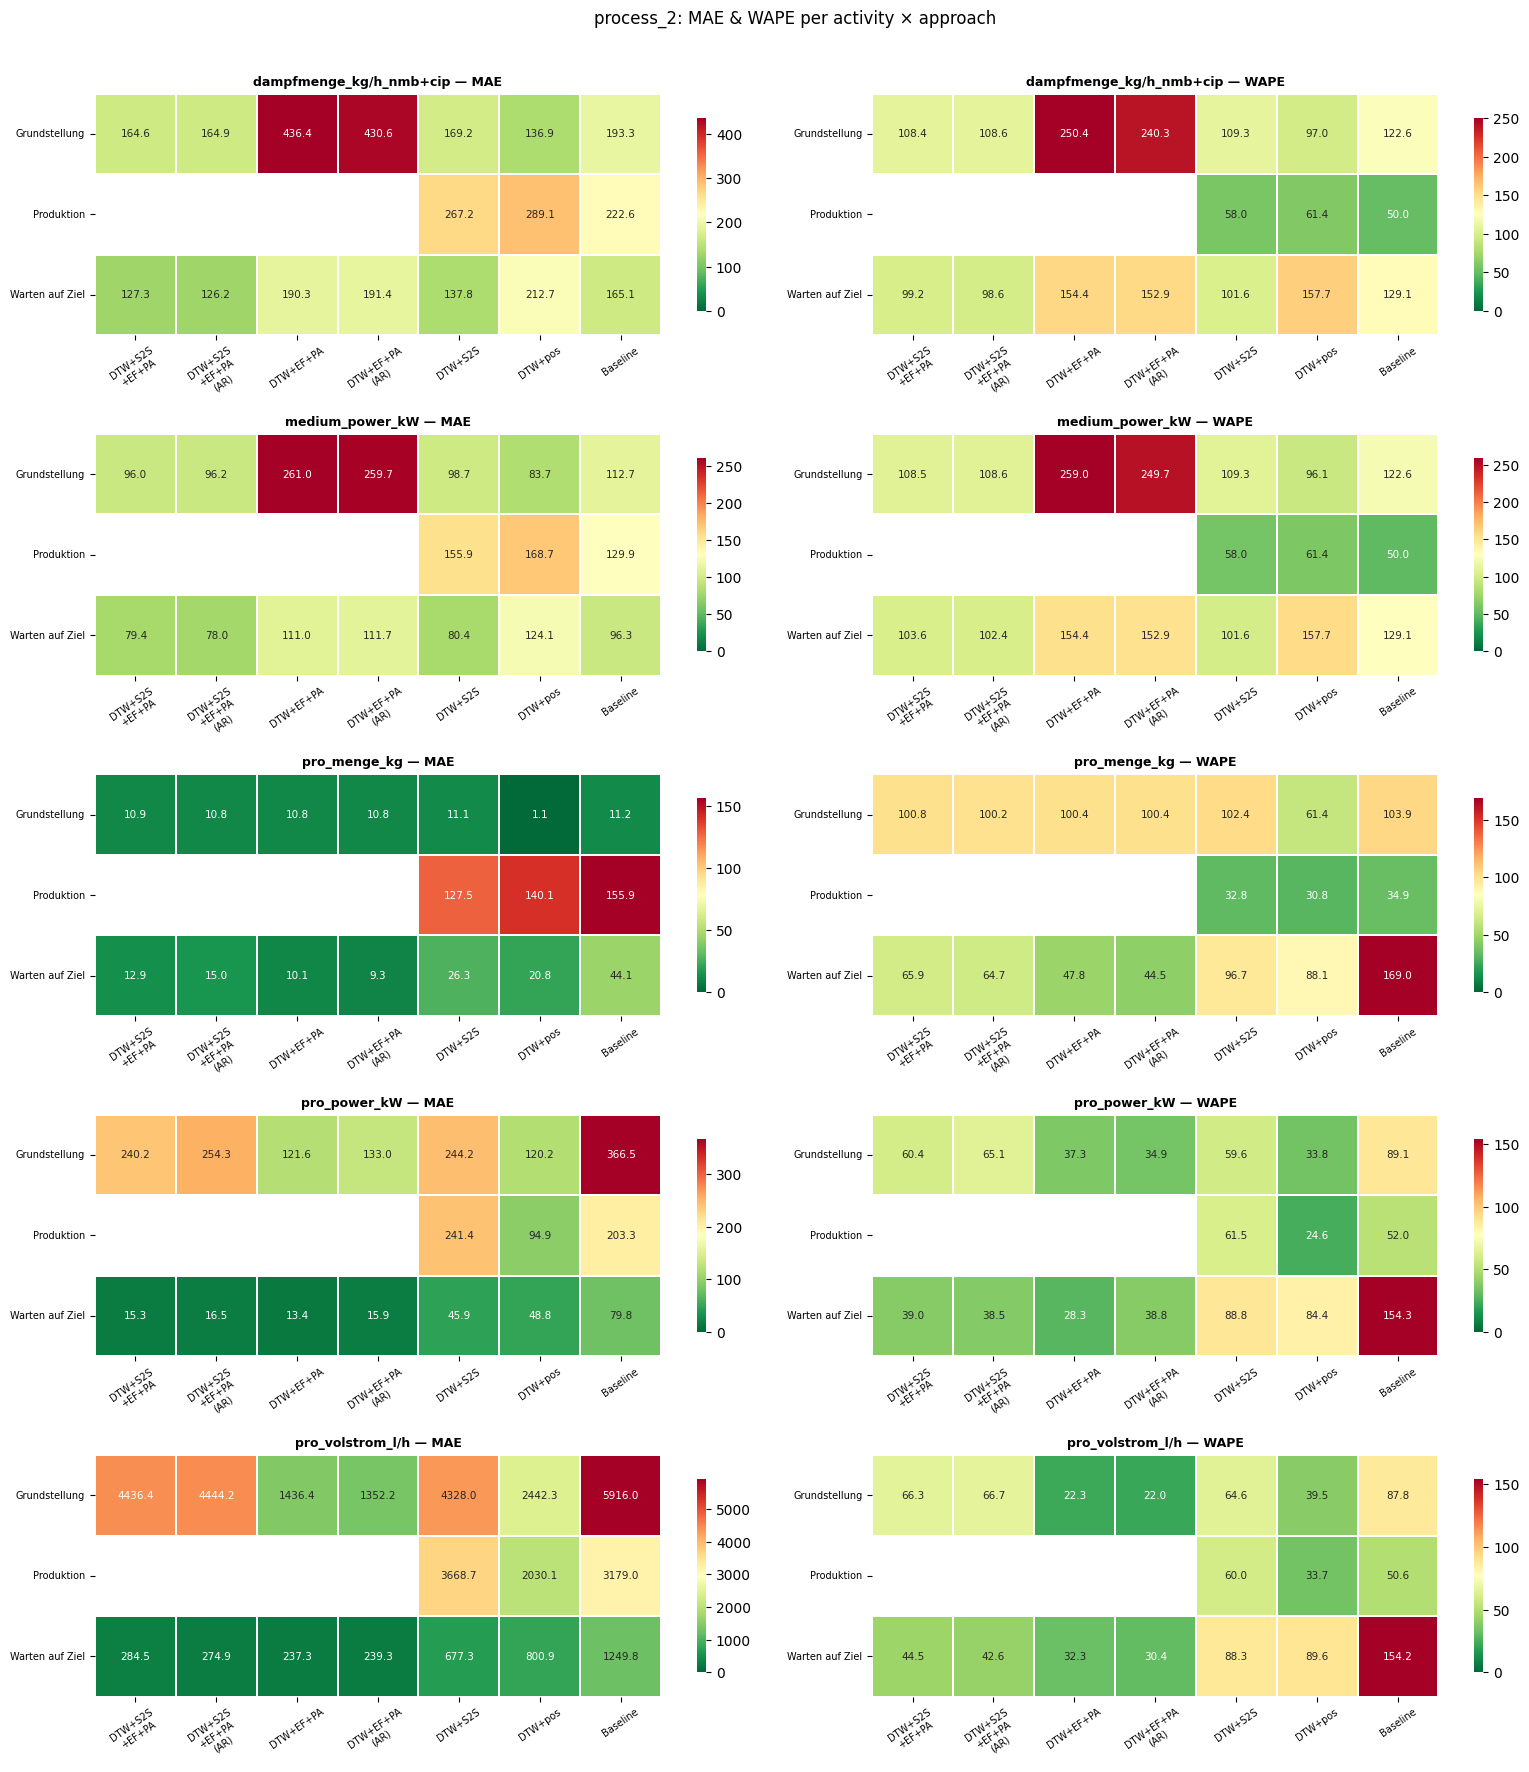

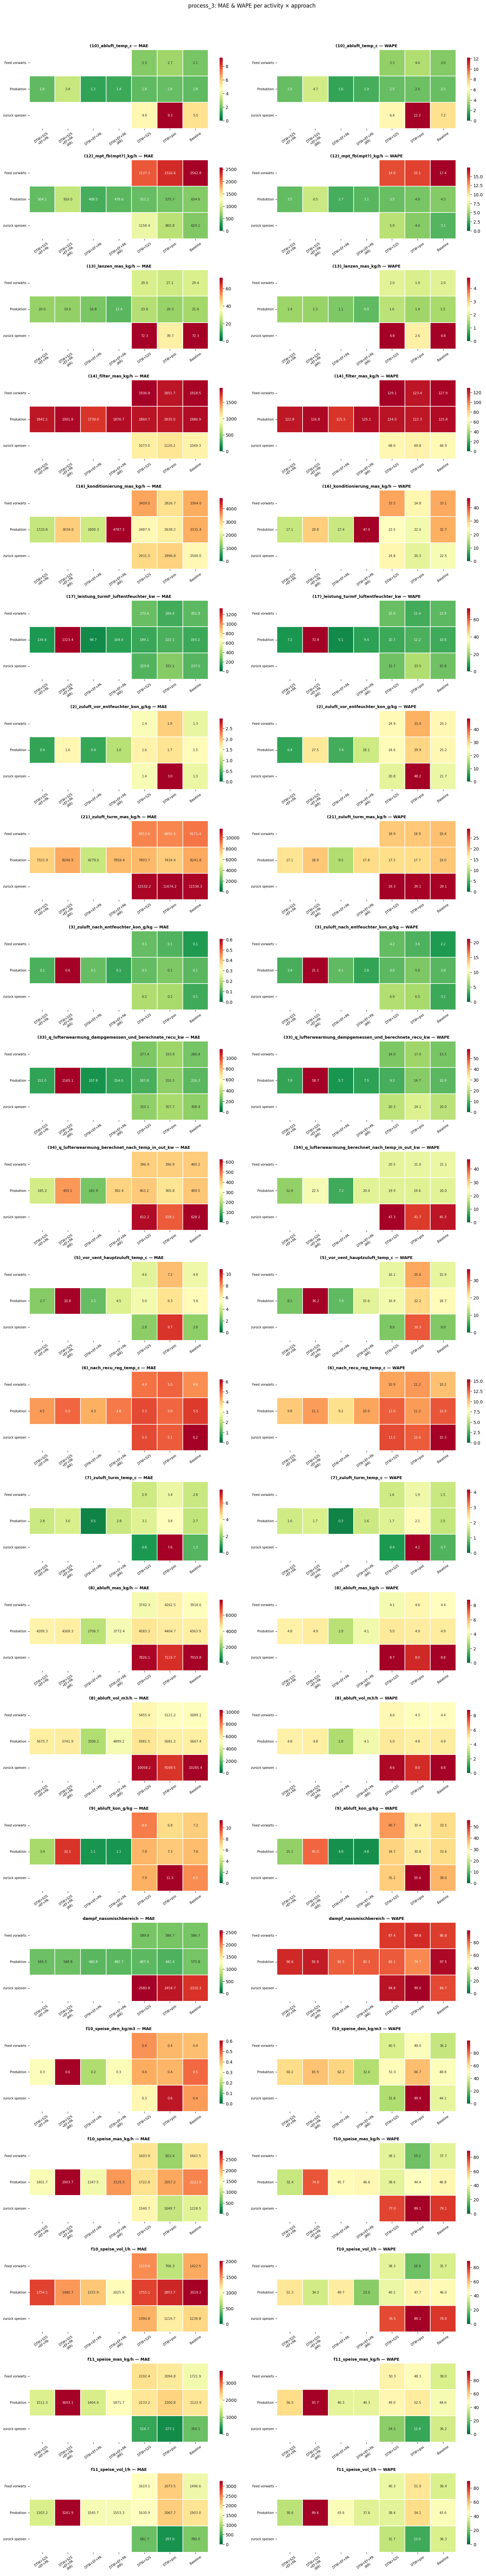

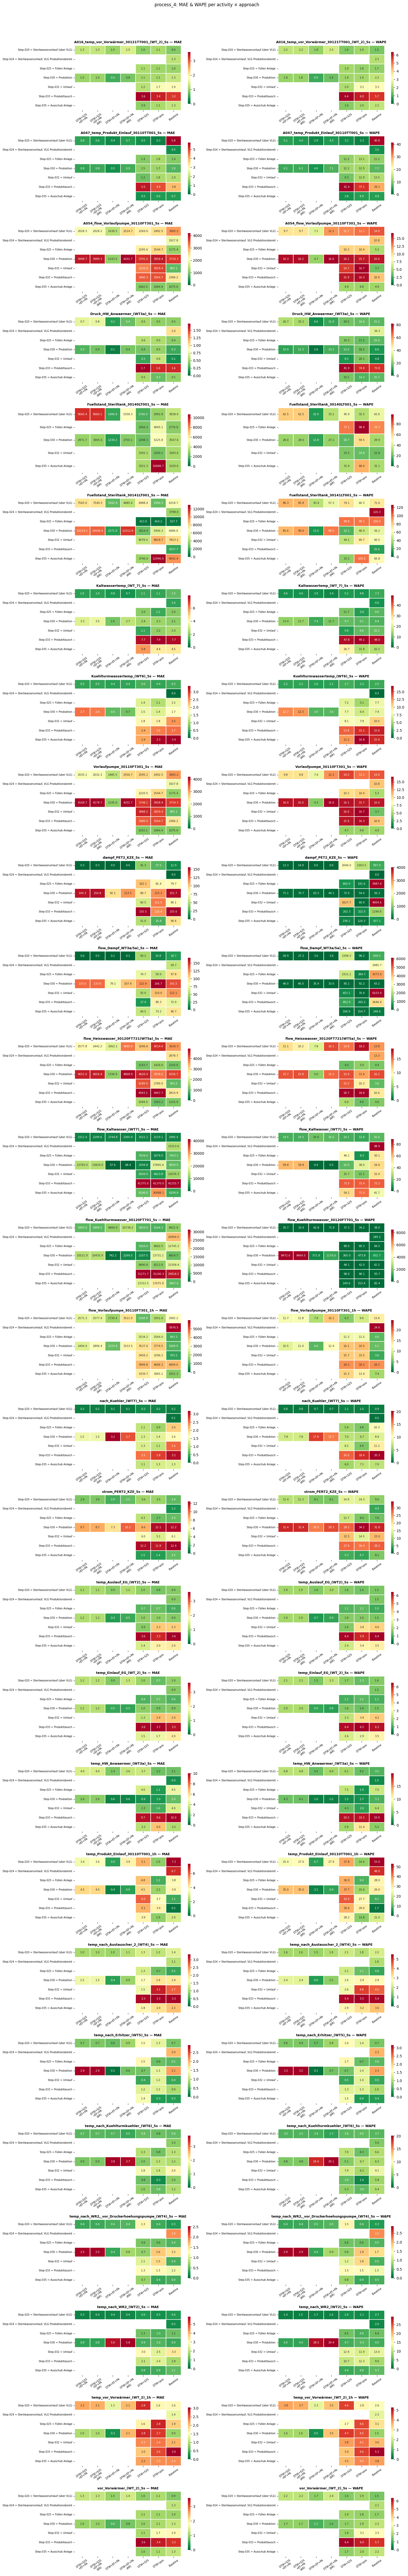

In [10]:
# Per-sensor heatmap: MAE and WAPE for each process × (sensor, approach)
for proc in sorted(test['Process'].unique()):
    df_p = test[test['Process'] == proc]
    sensors = sorted(df_p['Sensor'].unique())
    
    fig, axes = plt.subplots(len(sensors), 2,
                             figsize=(16, 3.5 * len(sensors)),
                             squeeze=False)
    
    for row, sensor in enumerate(sensors):
        df_s = df_p[df_p['Sensor'] == sensor]
        for col, metric in enumerate(['MAE', 'WAPE']):
            ax = axes[row][col]
            pivot = (df_s.groupby(['Activity', 'Approach_short'])[metric]
                     .median()
                     .unstack('Approach_short'))
            pivot = pivot[[c for c in approach_order if c in pivot.columns]]
            if pivot.empty:
                ax.set_visible(False); continue
            vmax = pivot.values[~np.isnan(pivot.values)].max() if pivot.notna().any().any() else 1
            sns.heatmap(pivot, ax=ax, annot=True, fmt='.1f', cmap='RdYlGn_r',
                        vmin=0, vmax=vmax,
                        linewidths=0.3, linecolor='white',
                        annot_kws={'size': 7.5}, cbar_kws={'shrink': 0.8})
            sname = sensor.replace('_energy_to_model', '')
            ax.set_title(f'{sname} — {metric}', fontsize=9, fontweight='bold')
            ax.set_xlabel(''); ax.set_ylabel('')
            ax.tick_params(axis='x', labelsize=7, rotation=35)
            ax.tick_params(axis='y', labelsize=7, rotation=0)
    
    fig.suptitle(f'{proc}: MAE & WAPE per activity × approach', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

---
## Improvement Strategies

Three angles to explore:

1. **Min-instance filter** — does performance improve when we only evaluate on activities with enough test observations (N ≥ threshold)?  
2. **Worst activities per process** — where exactly is the error concentrated?  
3. **Relative improvement over baseline** — which approaches reliably beat the mean baseline across all processes?

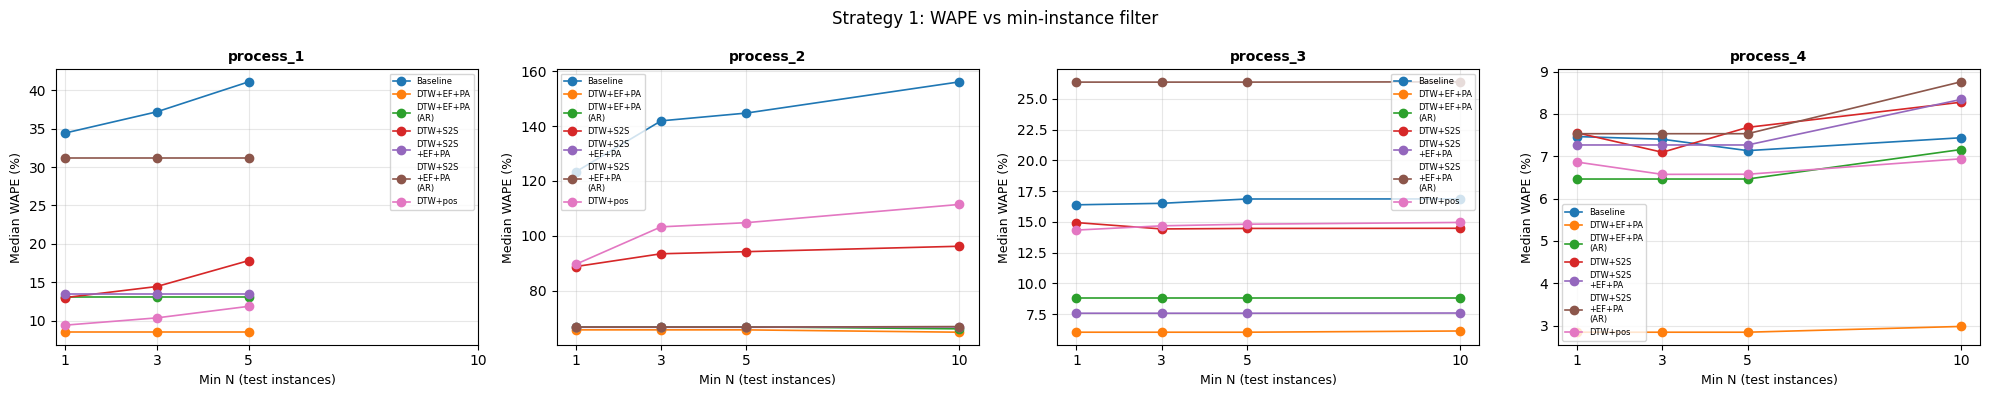

Counts surviving each filter (TEST, WAPE not NaN):
  N >=  1:  78358 rows (100%)
  N >=  3:  65381 rows (83%)
  N >=  5:  51827 rows (66%)
  N >= 10:  37869 rows (48%)


In [11]:
# Strategy 1 — Min-instance filter
# Activities with very few test instances are noisy; filter at several thresholds
# and see whether the ranking and absolute errors change.

thresholds = [1, 3, 5, 10]
summary_rows = []

for n_min in thresholds:
    filtered = test[test['N'] >= n_min]
    agg_f = (filtered.groupby(['Process', 'Approach_short'])[['MAE', 'WAPE']]
             .median()
             .reset_index())
    agg_f['N_min'] = n_min
    summary_rows.append(agg_f)

filter_df = pd.concat(summary_rows, ignore_index=True)

# Show how median WAPE changes with threshold, per process
fig, axes = plt.subplots(1, len(PROCESSES), figsize=(5 * len(PROCESSES), 4), sharey=False)
axes = np.array(axes).flatten()

for ax, proc in zip(axes, PROCESSES):
    sub = filter_df[filter_df['Process'] == proc]
    if sub.empty:
        ax.set_visible(False); continue
    for approach, grp in sub.groupby('Approach_short'):
        ax.plot(grp['N_min'], grp['WAPE'], marker='o', label=approach, linewidth=1.2)
    ax.set_title(proc, fontsize=10, fontweight='bold')
    ax.set_xlabel('Min N (test instances)', fontsize=9)
    ax.set_ylabel('Median WAPE (%)', fontsize=9)
    ax.legend(fontsize=6, ncol=1)
    ax.set_xticks(thresholds)
    ax.grid(True, alpha=0.3)

fig.suptitle('Strategy 1: WAPE vs min-instance filter', fontsize=12)
plt.tight_layout()
plt.show()

print('Counts surviving each filter (TEST, WAPE not NaN):')
for n_min in thresholds:
    n = (test['N'] >= n_min).sum()
    print(f'  N >= {n_min:2d}: {n:6d} rows ({100*n/len(test):.0f}%)')

Best approach per process (median WAPE):
  process_1: DTW+EF+PA
  process_2: DTW+EF+PA
  process_3: DTW+EF+PA
  process_4: DTW+EF+PA


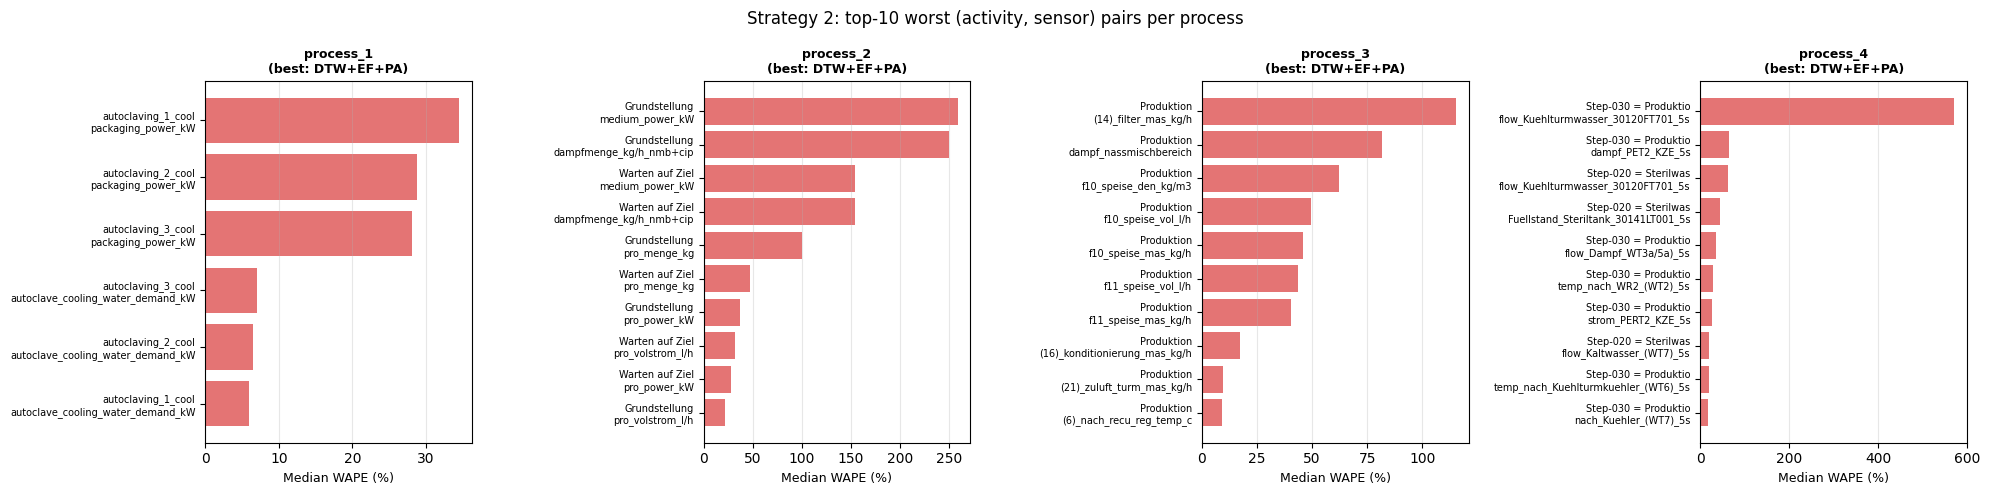

In [12]:
# Strategy 2 — Worst activities per process
# For the best approach (lowest median WAPE), show which activities have the
# highest error — these are the candidates for targeted improvement.

best_approach_per_proc = (
    agg.loc[agg.groupby('Process')['WAPE'].idxmin(), ['Process', 'Approach_short']]
    .set_index('Process')['Approach_short']
    .to_dict()
)
print('Best approach per process (median WAPE):')
for k, v in best_approach_per_proc.items():
    print(f'  {k}: {v}')

n_worst = 10
fig, axes = plt.subplots(1, len(PROCESSES), figsize=(5 * len(PROCESSES), 5), sharey=False)
axes = np.array(axes).flatten()

for ax, proc in zip(axes, PROCESSES):
    best_app = best_approach_per_proc.get(proc)
    if not best_app:
        ax.set_visible(False); continue
    sub = test[(test['Process'] == proc) & (test['Approach_short'] == best_app)]
    worst = (sub.groupby(['Activity', 'Sensor'])['WAPE']
             .median()
             .sort_values(ascending=False)
             .head(n_worst)
             .reset_index())
    worst['label'] = worst['Activity'].str[:20] + '\n' + worst['Sensor'].str.replace('_energy_to_model','')[:15]
    ax.barh(worst['label'][::-1], worst['WAPE'][::-1], color='#e05c5c', alpha=0.85)
    ax.set_title(f'{proc}\n(best: {best_app})', fontsize=9, fontweight='bold')
    ax.set_xlabel('Median WAPE (%)', fontsize=9)
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(True, axis='x', alpha=0.3)

fig.suptitle(f'Strategy 2: top-{n_worst} worst (activity, sensor) pairs per process', fontsize=12)
plt.tight_layout()
plt.show()

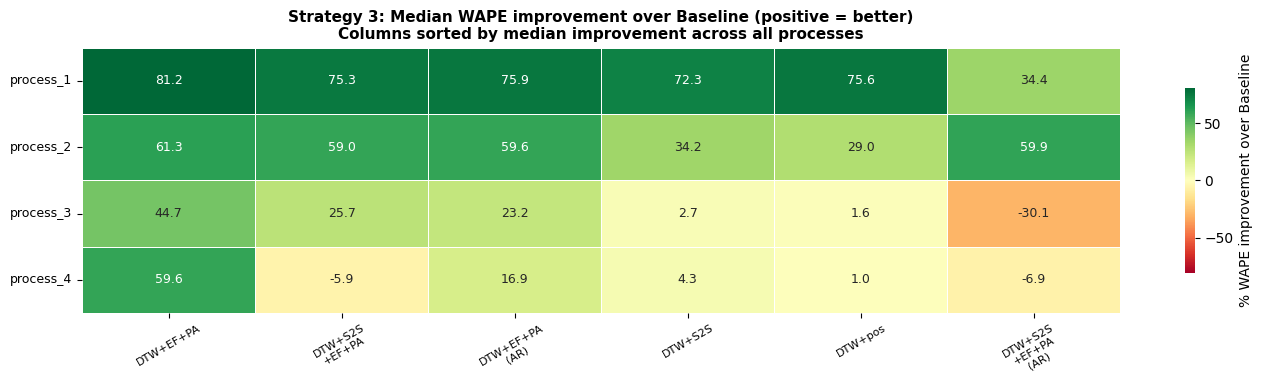


Median improvement across ALL processes (sorted):
Approach_short
DTW+EF+PA                +60.4%
DTW+S2S\n+EF+PA          +42.4%
DTW+EF+PA\n(AR)          +41.4%
DTW+S2S                  +19.2%
DTW+pos                  +15.3%
DTW+S2S\n+EF+PA\n(AR)    +13.7%


In [13]:
# Strategy 3 — Relative improvement over baseline
# For each (process, sensor, activity) row, compute how much each approach
# reduces WAPE relative to the Baseline.  Negative = better than baseline.
# Heatmap: process × approach, value = median % improvement.

baseline_wape = (
    test[test['Approach_short'] == 'Baseline']
    .set_index(['Process', 'Sensor', 'Activity'])['WAPE']
    .rename('baseline_wape')
)

test_imp = test.join(baseline_wape, on=['Process', 'Sensor', 'Activity'])
test_imp = test_imp[test_imp['baseline_wape'].notna() & (test_imp['baseline_wape'] > 0)]
test_imp['rel_improvement'] = 100 * (test_imp['baseline_wape'] - test_imp['WAPE']) / test_imp['baseline_wape']

agg_imp = (test_imp[test_imp['Approach_short'] != 'Baseline']
           .groupby(['Process', 'Approach_short'])['rel_improvement']
           .median()
           .reset_index())

pivot_imp = agg_imp.pivot(index='Process', columns='Approach_short', values='rel_improvement')
pivot_imp = pivot_imp.reindex(sorted(pivot_imp.index))
col_order_imp = pivot_imp.median().sort_values(ascending=False).index
pivot_imp = pivot_imp[col_order_imp]

fig, ax = plt.subplots(figsize=(14, 4))
vabs = max(abs(pivot_imp.values[~np.isnan(pivot_imp.values)].max()),
           abs(pivot_imp.values[~np.isnan(pivot_imp.values)].min()))
sns.heatmap(pivot_imp, ax=ax, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=-vabs, vmax=vabs,
            linewidths=0.4, linecolor='white',
            annot_kws={'size': 9}, cbar_kws={'label': '% WAPE improvement over Baseline', 'shrink': 0.7})
ax.set_title('Strategy 3: Median WAPE improvement over Baseline (positive = better)\n'
             'Columns sorted by median improvement across all processes',
             fontsize=11, fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=8, rotation=30)
ax.tick_params(axis='y', labelsize=9, rotation=0)
plt.tight_layout()
plt.show()

print('\nMedian improvement across ALL processes (sorted):')
print(agg_imp.groupby('Approach_short')['rel_improvement'].median()
      .sort_values(ascending=False)
      .apply(lambda x: f'{x:+.1f}%')
      .to_string())